In [1]:
from nocode_robot_programming.state_decision.utils import kill_other_ipykernels
kill_other_ipykernels(force=True)
import trajectory_data
import matplotlib.pyplot as plt
from nocode_robot_programming.state_decision.dataloader import TrajectoryDataset
from nocode_robot_programming.state_decision.dino_model import DINOStateDecider
from nocode_robot_programming.state_decision.SIFT_model import StateDeciderSIFT
from nocode_robot_programming.state_decision.AEGP_model import AEGP
from nocode_robot_programming.state_decision.state_decider import StateDeciderBase
from gesture_detector.utils import pretty_confusion_matrix
import torch
import numpy as np
import matplotlib.pyplot as plt

No other ipykernel_launcher processes found.


# Load trajectory loader dataset

- `TrajectoryDataset` loads trajectory files
- `TrajectoryDataset.tasks` task structure
- 

In [2]:
dataset = TrajectoryDataset(trajectory_data.package_path)

Found tasks:
Task               | # Files | Names (unique)                                                  | Trials | Offsets
-------------------+---------+-----------------------------------------------------------------+--------+--------
d1_peg_pick        | 11      | d1_peg_pick, d1_peg_pick_branch_at_49, … (+9 more)              | -1–8   | 0–49   
d1_probe           | 9       | d1_probe, d1_probe_branch_at_51, d1_probe_trial_0, … (+6 more)  | -1–6   | 0–51   
d2_peg_pick        | 7       | d2_peg_pick, d2_peg_pick_branch_at_76, … (+5 more)              | -1–4   | 0–76   
d2_probe           | 9       | d2_probe, d2_probe_branch_at_103, d2_probe_trial_0, … (+6 more) | -1–6   | 0–103  
d3_peg_pick        | 5       | d3_peg_pick, d3_peg_pick_branch_at_189, … (+3 more)             | -1–2   | 0–189  
d3_probe           | 5       | d3_probe, d3_probe_branch_at_118, d3_probe_trial_0, … (+2 more) | -1–2   | 0–118  
peg_door404        | 1       | peg_door404                                 

In [3]:
task_name = "d1_peg_pick"

d1_peg_pick  is discarded as an alternative branch


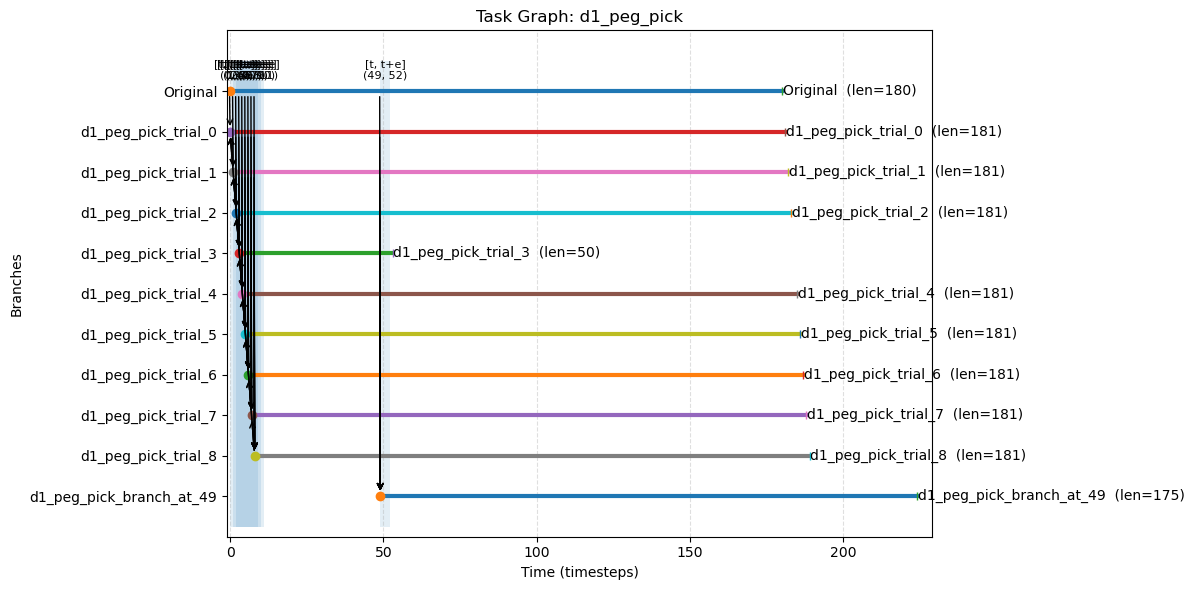

In [4]:
dataset.get_task_graph_structure(task_name)

In [5]:
dataset.tasks

{'d1_peg_pick': {'names': ['d1_peg_pick',
   'd1_peg_pick_branch_at_49',
   'd1_peg_pick_trial_0',
   'd1_peg_pick_trial_1',
   'd1_peg_pick_trial_2',
   'd1_peg_pick_trial_3',
   'd1_peg_pick_trial_4',
   'd1_peg_pick_trial_5',
   'd1_peg_pick_trial_6',
   'd1_peg_pick_trial_7',
   'd1_peg_pick_trial_8'],
  'offsets': [0, 49, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  'trials': [-1, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8],
  'files': ['d1_peg_pick',
   'd1_peg_pick_branch_at_49',
   'd1_peg_pick_trial_0',
   'd1_peg_pick_trial_1',
   'd1_peg_pick_trial_2',
   'd1_peg_pick_trial_3',
   'd1_peg_pick_trial_4',
   'd1_peg_pick_trial_5',
   'd1_peg_pick_trial_6',
   'd1_peg_pick_trial_7',
   'd1_peg_pick_trial_8']},
 'd1_probe': {'names': ['d1_probe',
   'd1_probe_branch_at_51',
   'd1_probe_trial_0',
   'd1_probe_trial_1',
   'd1_probe_trial_2',
   'd1_probe_trial_3',
   'd1_probe_trial_4',
   'd1_probe_trial_5',
   'd1_probe_trial_6'],
  'offsets': [0, 51, 0, 0, 0, 0, 0, 0, 0],
  'trials': [-1, -1, 0, 1, 2, 3

In [ ]:
d = dataset.get_image_dataset(dataset.tasks[task_name]['names'])

In [ ]:
d.X.shape

In [ ]:
# decider = DINOStateDecider()
# decider = StateDeciderSIFT()
decider = AEGP()
# decider = StateDeciderBase()

# Door Open/Close classification

In [ ]:
decider.train(d.X, d.y_int, d.y_cls)

In [39]:
def predict(decider, X):
    y_pred = []
    for x in X:
        y_label = decider.predict(x)
        y_pred.append(y_label)
    return y_pred

In [ ]:
plt.imshow(d.X[0].cpu())

In [ ]:
decider.videoembedder.model.eval()
image = d.X[0]
with torch.no_grad():
    latent = decider.videoembedder.model.encoder(image.unsqueeze(0).unsqueeze(0)) # (1, 1, width, height), 4D
    out = decider.videoembedder.model.decoder(latent)
plt.imshow(out.squeeze().detach().cpu())

In [ ]:
y_pred = predict(decider, d.X)

In [ ]:

pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls),len(decider.y_cls)))

# Dataset setup from demonstrations

- There are available tasks

In [7]:
print(dataset)

Task               | # Files | Names (unique)                                                  | Trials | Offsets
-------------------+---------+-----------------------------------------------------------------+--------+--------
d1_peg_pick        | 11      | d1_peg_pick, d1_peg_pick_branch_at_49, … (+9 more)              | -1–8   | 0–49   
d1_probe           | 9       | d1_probe, d1_probe_branch_at_51, d1_probe_trial_0, … (+6 more)  | -1–6   | 0–51   
d2_peg_pick        | 7       | d2_peg_pick, d2_peg_pick_branch_at_76, … (+5 more)              | -1–4   | 0–76   
d2_probe           | 9       | d2_probe, d2_probe_branch_at_103, d2_probe_trial_0, … (+6 more) | -1–6   | 0–103  
d3_peg_pick        | 5       | d3_peg_pick, d3_peg_pick_branch_at_189, … (+3 more)             | -1–2   | 0–189  
d3_probe           | 5       | d3_probe, d3_probe_branch_at_118, d3_probe_trial_0, … (+2 more) | -1–2   | 0–118  
peg_door404        | 1       | peg_door404                                              

I select the `d1_peg_pick`

In [8]:
task_name = "d1_peg_pick"

- There are skill variations (demonstrations) for this task

In [10]:
dataset.tasks[task_name]['names']

['d1_peg_pick',
 'd1_peg_pick_branch_at_49',
 'd1_peg_pick_trial_0',
 'd1_peg_pick_trial_1',
 'd1_peg_pick_trial_2',
 'd1_peg_pick_trial_3',
 'd1_peg_pick_trial_4',
 'd1_peg_pick_trial_5',
 'd1_peg_pick_trial_6',
 'd1_peg_pick_trial_7',
 'd1_peg_pick_trial_8']

- I need to label each trial with a `tag`

# Dataset Option 1: Use just original and recovery motion

In [53]:
def option1_discard_trials(dataset, task_name):
    return [s for s in dataset.tasks[task_name]['names'] if "_trial_" not in s]

In [54]:
d = dataset.get_image_dataset(option1_discard_trials(dataset, task_name))

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/doma/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


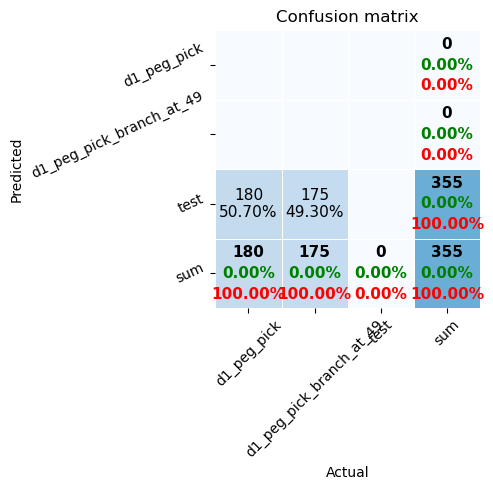

/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


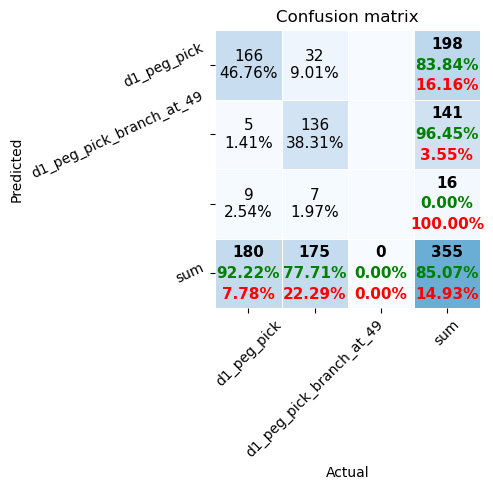

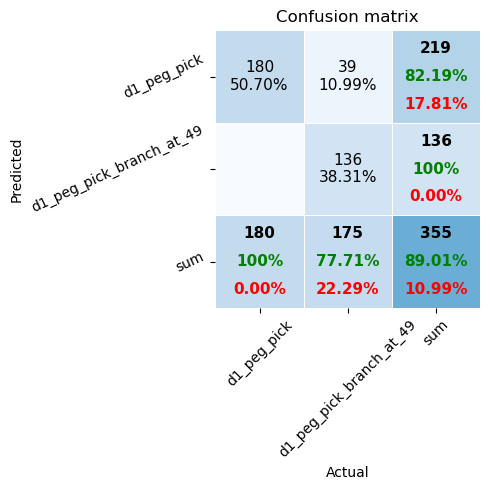

Epoch [49/50], Trainloss: 0.73, ValLoss: 0.00687: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]  


mean_probs tensor([[0.9420, 0.0580]], device='cuda:0')
mean_probs tensor([[0.9403, 0.0597]], device='cuda:0')
mean_probs tensor([[0.9368, 0.0632]], device='cuda:0')
mean_probs tensor([[0.9344, 0.0656]], device='cuda:0')
mean_probs tensor([[0.9333, 0.0667]], device='cuda:0')
mean_probs tensor([[0.9317, 0.0683]], device='cuda:0')
mean_probs tensor([[0.9328, 0.0672]], device='cuda:0')
mean_probs tensor([[0.9399, 0.0601]], device='cuda:0')
mean_probs tensor([[0.9497, 0.0503]], device='cuda:0')
mean_probs tensor([[0.9446, 0.0554]], device='cuda:0')
mean_probs tensor([[0.9436, 0.0564]], device='cuda:0')
mean_probs tensor([[0.9571, 0.0429]], device='cuda:0')
mean_probs tensor([[0.9392, 0.0608]], device='cuda:0')
mean_probs tensor([[0.9397, 0.0603]], device='cuda:0')
mean_probs tensor([[0.9354, 0.0646]], device='cuda:0')
mean_probs tensor([[0.9447, 0.0553]], device='cuda:0')
mean_probs tensor([[0.9598, 0.0402]], device='cuda:0')
mean_probs tensor([[0.9512, 0.0488]], device='cuda:0')
mean_probs

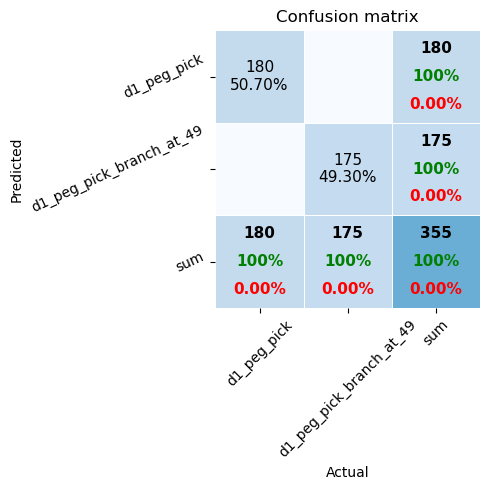

In [ ]:

for decider in [
    StateDeciderBase(),
    DINOStateDecider(),
    StateDeciderSIFT(),
    AEGP(),
    ]:
    decider.train(d.X, d.y_int, d.y_cls)
    y_pred = predict(decider, d.X)
    pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


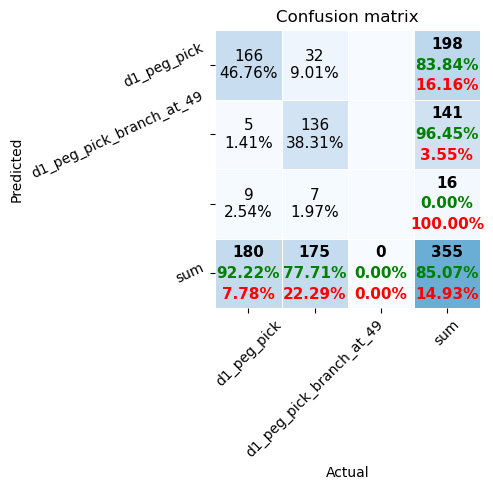

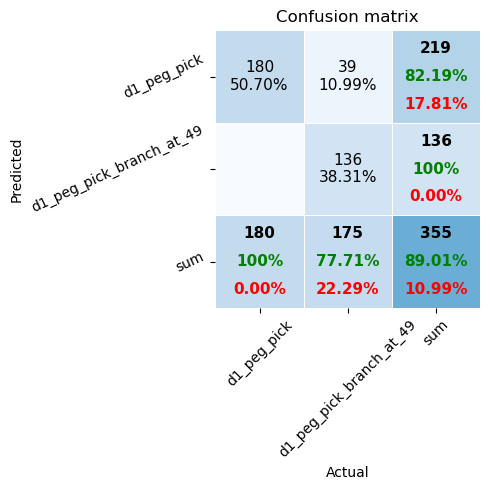

Epoch [49/50], Trainloss: 0.474, ValLoss: 0.002276: 100%|██████████| 50/50 [00:58<00:00,  1.17s/it]


mean_probs tensor([[0.9067, 0.0933]], device='cuda:0')
mean_probs tensor([[0.9091, 0.0909]], device='cuda:0')
mean_probs tensor([[0.8855, 0.1145]], device='cuda:0')
mean_probs tensor([[0.8848, 0.1152]], device='cuda:0')
mean_probs tensor([[0.8721, 0.1279]], device='cuda:0')
mean_probs tensor([[0.8711, 0.1289]], device='cuda:0')
mean_probs tensor([[0.8491, 0.1509]], device='cuda:0')
mean_probs tensor([[0.8668, 0.1332]], device='cuda:0')
mean_probs tensor([[0.8644, 0.1356]], device='cuda:0')
mean_probs tensor([[0.8738, 0.1262]], device='cuda:0')
mean_probs tensor([[0.8767, 0.1233]], device='cuda:0')
mean_probs tensor([[0.9047, 0.0953]], device='cuda:0')
mean_probs tensor([[0.8677, 0.1323]], device='cuda:0')
mean_probs tensor([[0.8653, 0.1347]], device='cuda:0')
mean_probs tensor([[0.8361, 0.1639]], device='cuda:0')
mean_probs tensor([[0.8656, 0.1344]], device='cuda:0')
mean_probs tensor([[0.8923, 0.1077]], device='cuda:0')
mean_probs tensor([[0.8806, 0.1194]], device='cuda:0')
mean_probs

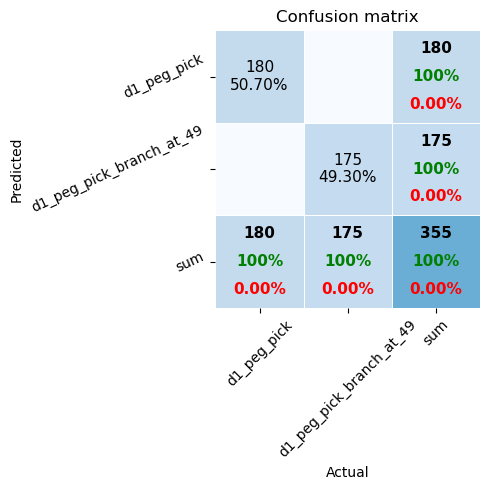

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


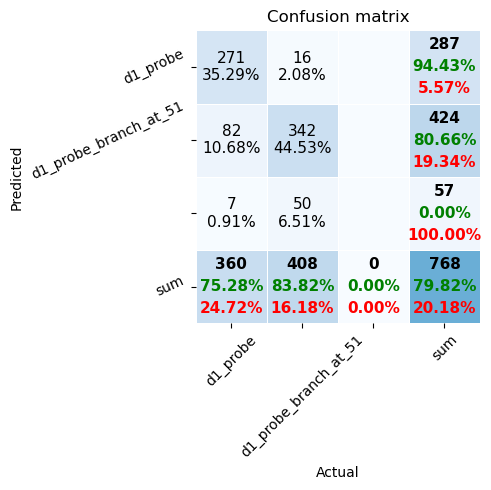

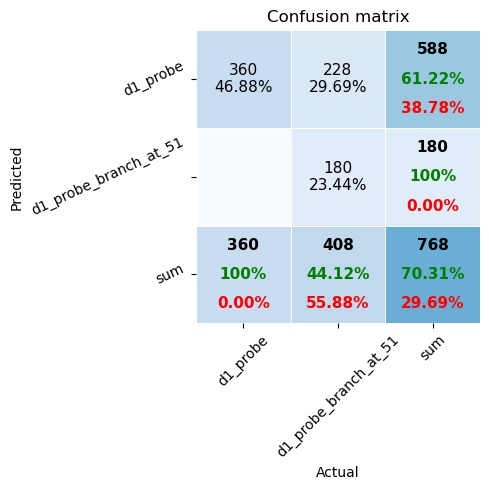

Epoch [49/50], Trainloss: 0.409, ValLoss: 0.004202: 100%|██████████| 50/50 [02:03<00:00,  2.47s/it]


mean_probs tensor([[0.4774, 0.5226]], device='cuda:0')
mean_probs tensor([[0.4769, 0.5231]], device='cuda:0')
mean_probs tensor([[0.4471, 0.5529]], device='cuda:0')
mean_probs tensor([[0.4605, 0.5395]], device='cuda:0')
mean_probs tensor([[0.4589, 0.5411]], device='cuda:0')
mean_probs tensor([[0.4510, 0.5490]], device='cuda:0')
mean_probs tensor([[0.4581, 0.5419]], device='cuda:0')
mean_probs tensor([[0.4512, 0.5488]], device='cuda:0')
mean_probs tensor([[0.4659, 0.5341]], device='cuda:0')
mean_probs tensor([[0.4552, 0.5448]], device='cuda:0')
mean_probs tensor([[0.4624, 0.5376]], device='cuda:0')
mean_probs tensor([[0.4624, 0.5376]], device='cuda:0')
mean_probs tensor([[0.4735, 0.5265]], device='cuda:0')
mean_probs tensor([[0.4670, 0.5330]], device='cuda:0')
mean_probs tensor([[0.4793, 0.5207]], device='cuda:0')
mean_probs tensor([[0.4703, 0.5297]], device='cuda:0')
mean_probs tensor([[0.4590, 0.5410]], device='cuda:0')
mean_probs tensor([[0.4530, 0.5470]], device='cuda:0')
mean_probs

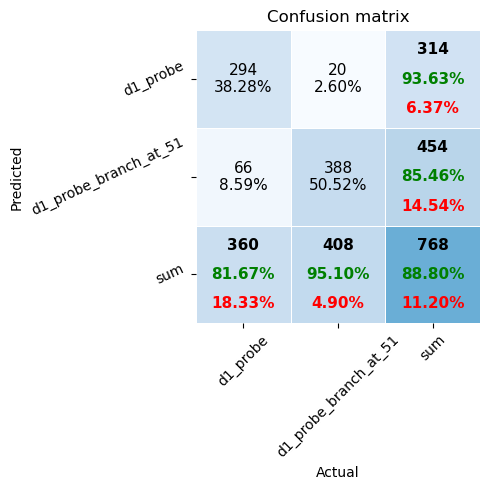

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


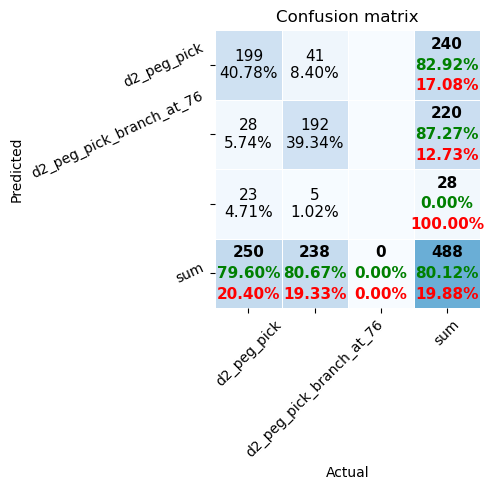

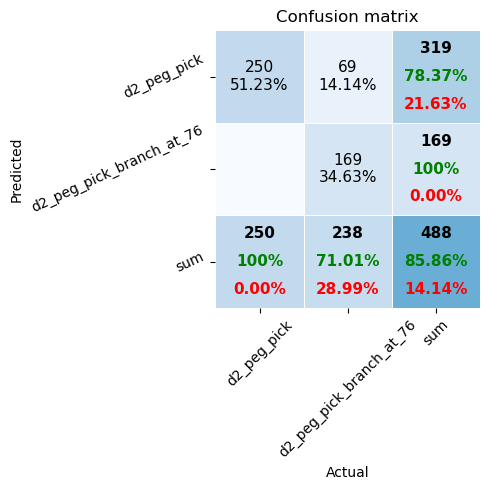

Epoch [49/50], Trainloss: 0.307, ValLoss: 0.002766: 100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


mean_probs tensor([[0.9484, 0.0516]], device='cuda:0')
mean_probs tensor([[0.9429, 0.0571]], device='cuda:0')
mean_probs tensor([[0.9421, 0.0579]], device='cuda:0')
mean_probs tensor([[0.9276, 0.0724]], device='cuda:0')
mean_probs tensor([[0.9407, 0.0593]], device='cuda:0')
mean_probs tensor([[0.9256, 0.0744]], device='cuda:0')
mean_probs tensor([[0.9694, 0.0306]], device='cuda:0')
mean_probs tensor([[0.9789, 0.0211]], device='cuda:0')
mean_probs tensor([[0.9717, 0.0283]], device='cuda:0')
mean_probs tensor([[0.9758, 0.0242]], device='cuda:0')
mean_probs tensor([[0.9710, 0.0290]], device='cuda:0')
mean_probs tensor([[0.9690, 0.0310]], device='cuda:0')
mean_probs tensor([[0.9669, 0.0331]], device='cuda:0')
mean_probs tensor([[0.9644, 0.0356]], device='cuda:0')
mean_probs tensor([[0.9427, 0.0573]], device='cuda:0')
mean_probs tensor([[0.9471, 0.0529]], device='cuda:0')
mean_probs tensor([[0.8971, 0.1029]], device='cuda:0')
mean_probs tensor([[0.8066, 0.1934]], device='cuda:0')
mean_probs

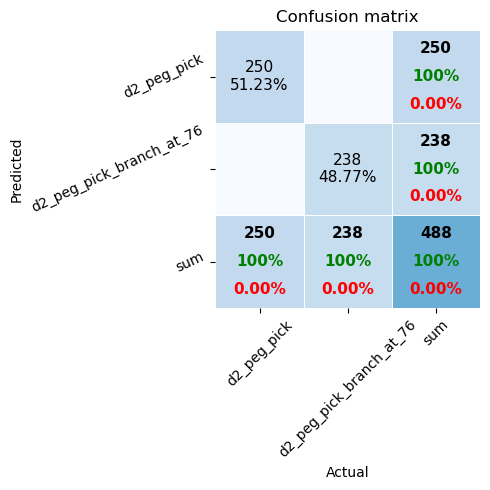

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


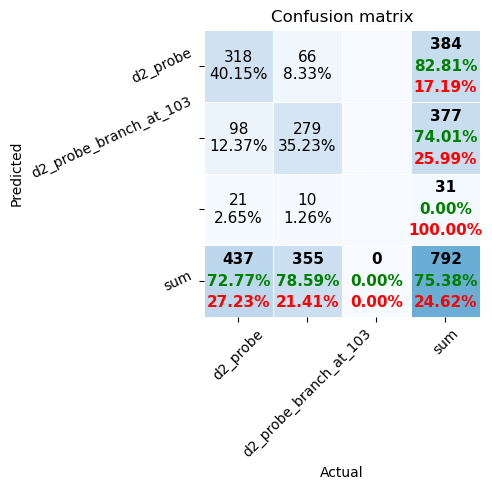

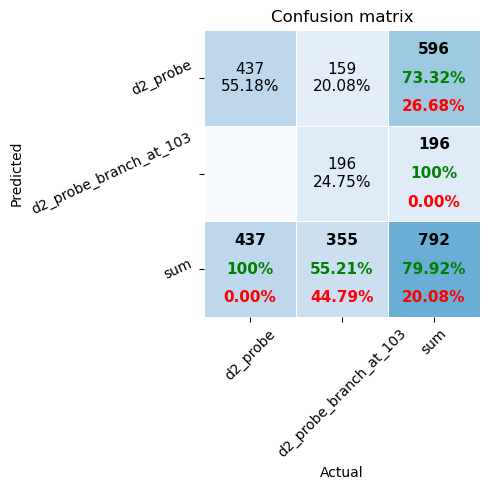

Epoch [49/50], Trainloss: 0.334, ValLoss: 0.005599: 100%|██████████| 50/50 [02:09<00:00,  2.59s/it]


mean_probs tensor([[0.9324, 0.0676]], device='cuda:0')
mean_probs tensor([[0.9463, 0.0537]], device='cuda:0')
mean_probs tensor([[0.9077, 0.0923]], device='cuda:0')
mean_probs tensor([[0.9235, 0.0765]], device='cuda:0')
mean_probs tensor([[0.9299, 0.0701]], device='cuda:0')
mean_probs tensor([[0.9026, 0.0974]], device='cuda:0')
mean_probs tensor([[0.9666, 0.0334]], device='cuda:0')
mean_probs tensor([[0.9440, 0.0560]], device='cuda:0')
mean_probs tensor([[0.8665, 0.1335]], device='cuda:0')
mean_probs tensor([[0.7897, 0.2103]], device='cuda:0')
mean_probs tensor([[0.8581, 0.1419]], device='cuda:0')
mean_probs tensor([[0.9033, 0.0967]], device='cuda:0')
mean_probs tensor([[0.9781, 0.0219]], device='cuda:0')
mean_probs tensor([[0.9941, 0.0059]], device='cuda:0')
mean_probs tensor([[0.9953, 0.0047]], device='cuda:0')
mean_probs tensor([[0.9979, 0.0021]], device='cuda:0')
mean_probs tensor([[0.9973, 0.0027]], device='cuda:0')
mean_probs tensor([[0.9980, 0.0020]], device='cuda:0')
mean_probs

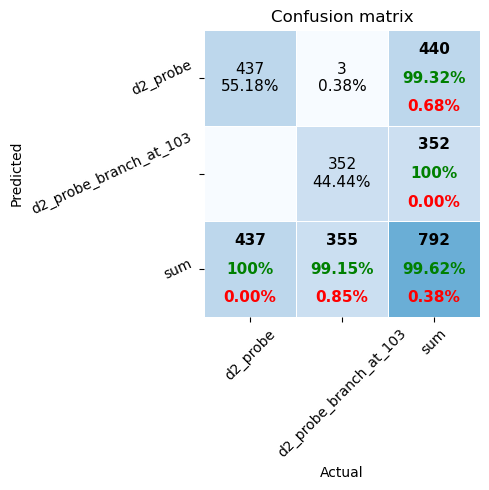

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


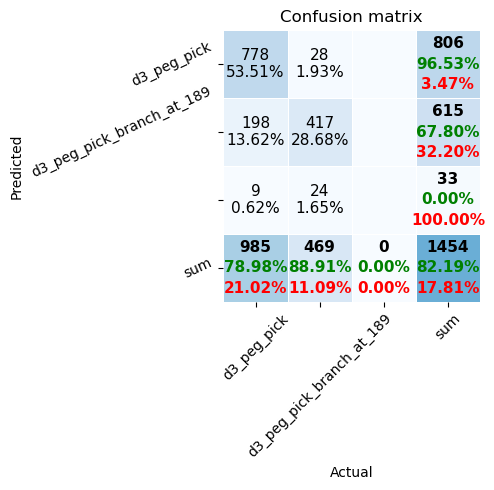

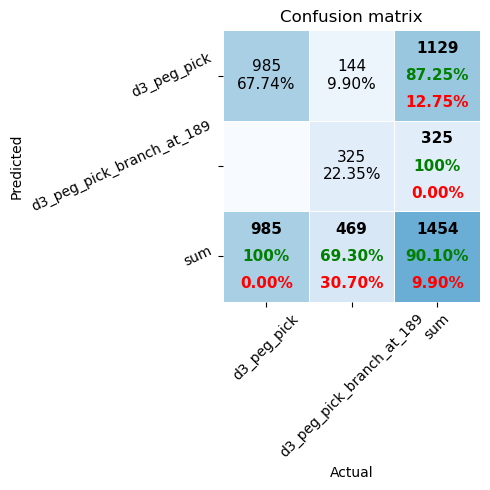

Epoch [49/50], Trainloss: 0.244, ValLoss: 0.002405: 100%|██████████| 50/50 [03:53<00:00,  4.68s/it]


mean_probs tensor([[0.9449, 0.0551]], device='cuda:0')
mean_probs tensor([[0.9481, 0.0519]], device='cuda:0')
mean_probs tensor([[0.9301, 0.0699]], device='cuda:0')
mean_probs tensor([[0.9452, 0.0548]], device='cuda:0')
mean_probs tensor([[0.9527, 0.0473]], device='cuda:0')
mean_probs tensor([[0.9429, 0.0571]], device='cuda:0')
mean_probs tensor([[0.9459, 0.0541]], device='cuda:0')
mean_probs tensor([[0.9400, 0.0600]], device='cuda:0')
mean_probs tensor([[0.9483, 0.0517]], device='cuda:0')
mean_probs tensor([[0.9484, 0.0516]], device='cuda:0')
mean_probs tensor([[0.9545, 0.0455]], device='cuda:0')
mean_probs tensor([[0.9541, 0.0459]], device='cuda:0')
mean_probs tensor([[0.9562, 0.0438]], device='cuda:0')
mean_probs tensor([[0.9570, 0.0430]], device='cuda:0')
mean_probs tensor([[0.9592, 0.0408]], device='cuda:0')
mean_probs tensor([[0.9574, 0.0426]], device='cuda:0')
mean_probs tensor([[0.9593, 0.0407]], device='cuda:0')
mean_probs tensor([[0.9629, 0.0371]], device='cuda:0')
mean_probs

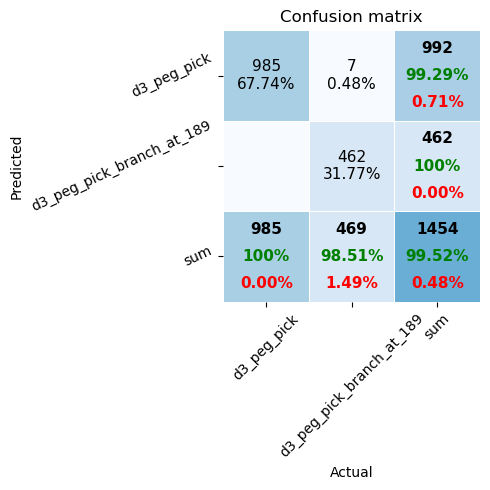

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


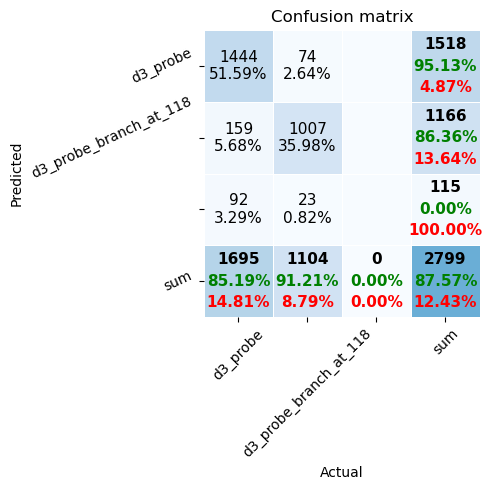

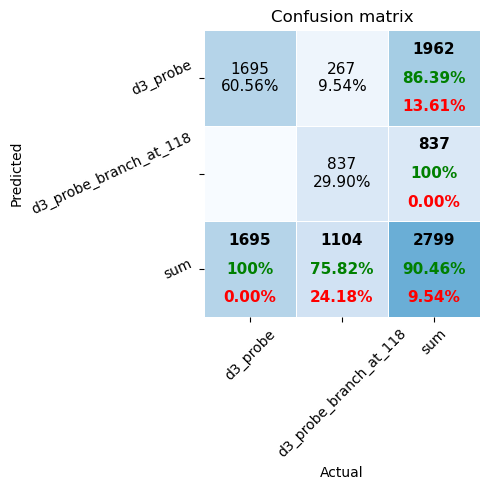

Epoch [49/50], Trainloss: 0.218, ValLoss: 0.002533: 100%|██████████| 50/50 [07:44<00:00,  9.29s/it]


mean_probs tensor([[0.9581, 0.0419]], device='cuda:0')
mean_probs tensor([[0.9565, 0.0435]], device='cuda:0')
mean_probs tensor([[0.9563, 0.0437]], device='cuda:0')
mean_probs tensor([[0.9593, 0.0407]], device='cuda:0')
mean_probs tensor([[0.9597, 0.0403]], device='cuda:0')
mean_probs tensor([[0.9542, 0.0458]], device='cuda:0')
mean_probs tensor([[0.9606, 0.0394]], device='cuda:0')
mean_probs tensor([[0.9529, 0.0471]], device='cuda:0')
mean_probs tensor([[0.9471, 0.0529]], device='cuda:0')
mean_probs tensor([[0.9543, 0.0457]], device='cuda:0')
mean_probs tensor([[0.9446, 0.0554]], device='cuda:0')
mean_probs tensor([[0.9426, 0.0574]], device='cuda:0')
mean_probs tensor([[0.9383, 0.0617]], device='cuda:0')
mean_probs tensor([[0.9243, 0.0757]], device='cuda:0')
mean_probs tensor([[0.9118, 0.0882]], device='cuda:0')
mean_probs tensor([[0.7753, 0.2247]], device='cuda:0')
mean_probs tensor([[0.7708, 0.2292]], device='cuda:0')
mean_probs tensor([[0.8515, 0.1485]], device='cuda:0')
mean_probs

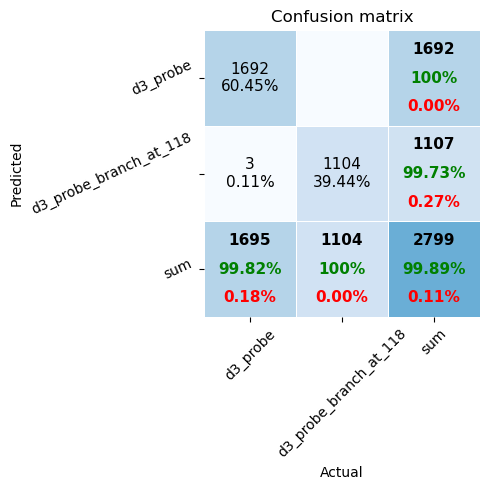

Using cache found in /home/doma/.cache/torch/hub/facebookresearch_dinov2_main
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  torch.cuda.amp.autocast(enabled=self.device.type == "cuda")
/home/doma/lfd_ws/build/nocode_robot_programming/nocode_robot_programming/state_decision/dino_model.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.type == "cuda"):


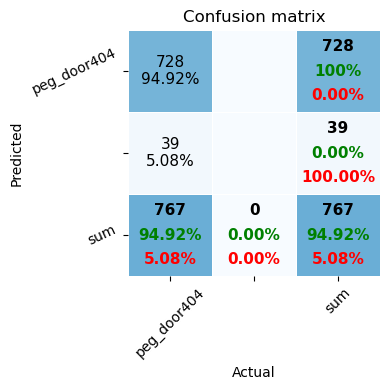

KeyboardInterrupt: 

In [55]:

for task_name in dataset.tasks.keys():
    d = dataset.get_image_dataset(option1_discard_trials(dataset, task_name))
    for decider in [
            DINOStateDecider(),
            StateDeciderSIFT(),
            AEGP(),
        ]:
        decider.train(d.X, d.y_int, d.y_cls)
        y_pred = predict(decider, d.X)
        
        pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(len(decider.y_cls)+3,len(decider.y_cls)+3), name=decider.__class__.__name__)

# Dataset d1 evaluation

- Keep initial settings, do not finetune the methods.
- Problems of this evaluation: Just training dataset, not splitting into train/test -> next steps, this is just proof if it can learn, not generalize
- There are no anomalies in the dataset while the models can trigger it.
- What is estimated? The original demonstration has a peg at location A, recovery has at location B. In the image, the peg is not visible at location A, estimator switches to recovery motion.

task name                       | modality | DINO | SIFT | AE-GP        
------------------------------- | -------- | ---- | ---- | ----
d1_peg_pick                     | kine     | 85%  | 89%  | 100% 
d2_peg_pick                     | joystick | 80.1%| 85.8%| 100%
d3_peg_pick                     | gestures | 82.2%| 90.0%| 99.5%
d1_probe                        | kine     | 79.8%| 70.3%| 88.8%
d2_probe                        | joystick | 75.4%| 79.9%| 99.6%
d3_probe                        | gestures | 87.5%| 90.5%| 99.89%

Total: 2 tasks, 12 demonstrations, 3 modalities

Download link (need CIIRC permission) at: https://drive.google.com/drive/folders/1WAZegaslnaMCgeS_O-wCrwGM7oJdXuNA?usp=sharing

### Next steps:

- [ ] tag the skill variations
- [ ] train/test dataset subsets
- [ ] Retrain
- [ ] Finetune & work on each methods
- [ ] Trigger anomaly (make a dataset) from the unseen data and evaluate the models